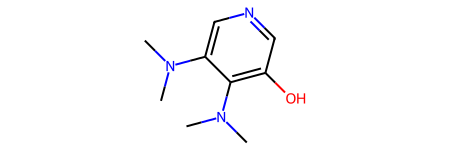

In [2]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
import cairosvg
import io


import pickle
import matplotlib.pyplot as plt
# import torch
import numpy as np
# from dqn import MolDQN
from rdkit.Chem import QED
# from beautifultable import BeautifulTable, BTRowCollection
# from prettytable import PrettyTable

import pandas as pd
import pickle
# import joblib
# from molbert.utils.featurizer.molbert_featurizer import MolBertFeaturizer

from rdkit import RDConfig
import os
import sys
# sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
# import sascorer

from rdkit.DataManip.Metric import GetTanimotoDistMat
from rdkit.DataManip.Metric import GetTanimotoSimMat

IPythonConsole.ipython_useSVG=True
import random

Chem.MolFromSmiles('CN(C)c1cncc(O)c1N(C)C')


In [39]:
s = 'CC(=O)Nc1ccccc1NC(=O)COc2ccccc2'
mol = Chem.MolFromSmiles(s)
print(f'NumAtoms with Hs: {mol.GetNumAtoms()}')

print(sascorer.calculateScore(mol))
mhs = Chem.Mol(mol)
mhs = Chem.AddHs(mhs)
print(f'NumAtoms without Hs: {mhs.GetNumAtoms()}')

a = morganFingerprintGen.GetFingerprintAsNumPy(mol)
b = morganFingerprintGen.GetFingerprintAsNumPy(mhs)

print(f'fp diff: {np.max(np.abs(a - b))}')


NumAtoms with Hs: 21
1.5617097742783237
NumAtoms without Hs: 37
fp diff: 255


In [38]:
fp = rdMolDescriptors.GetMorganFingerprint(mhs,2)  # <- 2 is the *radius* of the circular fingerprint
fps = fp.GetNonzeroElements()
score1 = 0.
nf = 0
for bitId, v in fps.items():
    nf += v
    sfp = bitId
    print(f'{bitId}:{v}')
    # score1 += _fscores.get(sfp, -4) * v
score1 /= nf

55253355:9
62162552:4
411967733:1
479382786:1
496477157:1
847961216:2
864674487:1
864942730:2
1069890803:2
1130134577:4
1317890852:1
1393383569:1
1510328189:2
1552771574:1
1590992696:2
1869791067:1
2113675549:1
2115476908:1
2245384272:1
2246699815:2
2246728737:1
2382942914:1
2392445291:5
2847280337:2
3021641612:2
3162837314:1
3217380708:3
3218693969:9
3296331893:1
3309593724:2
3315826729:1
3321501787:3
3430458254:1
3434436707:1
3949216101:2
4041573576:2
4277593716:16


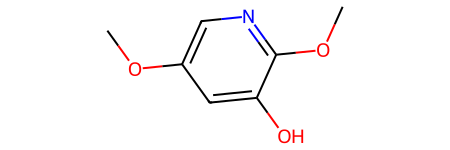

In [4]:
# s = '[H]OC1([H])OC2([H])C1([H])OC21C([H])([H])C1([H])[H]'
s = 'COc1cnc(OC)c(O)c1'
mol = Chem.MolFromSmiles(s)
mol

In [2]:
def mol_to_png(mol, file_name, h = None, l = '', width=300, height=200):
    full_path = f'./Results/{file_name}.png'
    # Render high resolution molecule
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    drawer.DrawMolecule(mol, highlightAtoms=h, legend=l)
    drawer.FinishDrawing()

    # Export to pdf
    cairosvg.svg2png(bytestring=drawer.GetDrawingText().encode(), write_to=full_path)

def draw_with_same(mol1, mol2, file_name, l = ''):
    mcs = rdFMCS.FindMCS([mol1,mol2])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    
    if mol1.GetNumAtoms() <= mol2.GetNumAtoms():
        
        match2 = mol2.GetSubstructMatch(mcs_mol)
        target_atm2 = []
        for atom in mol2.GetAtoms():
            # if atom.GetIdx() not in match2:
            if atom.GetIdx() in match2:
                target_atm2.append(atom.GetIdx())
        mol_to_png(mol2, file_name, target_atm2, l)
    else:
        pass
        # match1 = mol1.GetSubstructMatch(mcs_mol)
        # r = Chem.RWMol(mol1)
        # r.BeginBatchEdit()
        # for atom in mol1.GetAtoms():
        #     if atom.GetIdx() in match1:
        #         r.RemoveAtom(atom.GetIdx())
        # r.CommitBatchEdit()
        # rs = Chem.MolToSmiles(r)
        # m2s = Chem.MolToSmiles(mol2)
        # ns = f'{m2s}.{rs}'
        # nm = Chem.MolFromSmiles(ns)
        
        # mcs2 = rdFMCS.FindMCS([nm,mol2])
        # mcs_mol2 = Chem.MolFromSmarts(mcs2.smartsString)
        # match3 = nm.GetSubstructMatch(mcs_mol2)
        # target_atmn = []
        # for atom in nm.GetAtoms():
        #     if atom.GetIdx() not in match3:
        #         target_atmn.append(atom.GetIdx())
        # mol_to_png(nm, file_name, target_atmn, l)

s = 'COc1cnc(OC)c(O)c1'
mol = Chem.MolFromSmiles(s)
s2 = 'CCOc1cnc(OC)c(O)c1'
mol2 = Chem.MolFromSmiles(s2)
draw_with_same(mol, mol2, 'example_test')
        

In [25]:
def get_cs(mol, nm = [], aid = 0):
    c_add = (0.8, 0, 0)
    c_mod = (0, 0.8, 0.8)
    atom_cols = {}
    for i in nm:
        if i == aid:
            atom_cols[i] = c_add
        else:
            atom_cols[i] = c_mod
    return atom_cols
    
def mol_to_png(mol, file_name, h = [], aid = 0, l = '', width=1200, height=600):
    full_path = f'./Results/{file_name}.png'
    # Render high resolution molecule
    # for aid, a in enumerate(mol.GetAtoms()):
        # print(aid)
        # a.SetProp('atomNode
    
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    # drawer.drawOptions().addAtomIndices = True
    drawer.DrawMolecule(mol, highlightAtoms=h, highlightAtomColors=get_cs(mol, h, aid),legend=l)
    drawer.FinishDrawing()

    # Export to pdf
    cairosvg.svg2png(bytestring=drawer.GetDrawingText().encode(), write_to=full_path)

mol = Chem.MolFromSmiles('c0ccccc0CC')
mol_to_png(mol, 'example_imf_1', h = [0,1,3,4,5,6,7], aid = 7)
mol = Chem.MolFromSmiles('CN(C)CCCN(C(=O)C1COc2ccccc2O1)c1nc2cc3c(cc2s1)OC(=N)O3')
mol_to_png(mol, 'example_imf_2', h = [30,29,28,31,24,23,25,26,22,21], aid = 30)

In [35]:
# def draw_mols_from_path.

def read_pickles(reg):
    paths = glob.glob(f'./Experiments/{reg}')
    # files = [open(p, 'rb') for p in paths]
    # return [pickle.load(f) for f in files]
    rt = []
    for p in paths:
        f = open(p, 'rb')
        rt.append(pickle.load(f))
        f.close()
    return rt
        
p = read_pickles('maple_5_0_path*')
print(type(p[0]))
for k, v in p[0].items():
    print(k)
    print(type(v))

print('-------------------------------------')
tem = p[0]['last'][-1]
mols, rewards = tem
path = mols[4]
rewards = rewards['reward'][4]
print(path)
for i, mol in enumerate(path):
    # m = Chem.RWMol(mol)
    print(type(mol))
    print(mol)
    # s = Chem.MolToSmiles(mol)
    # print(s)
    m = mol
    mol_to_png(m, f'test_{i}')

<class 'dict'>
top
<class 'list'>
last
<class 'list'>
-------------------------------------
[<rdkit.Chem.rdchem.Mol object at 0x7f1563f43f60>, <rdkit.Chem.rdchem.Mol object at 0x7f15680ce570>, <rdkit.Chem.rdchem.Mol object at 0x7f15680ce660>, <rdkit.Chem.rdchem.Mol object at 0x7f15681aea70>, <rdkit.Chem.rdchem.Mol object at 0x7f15681aef70>, <rdkit.Chem.rdchem.Mol object at 0x7f15680cf0b0>, <rdkit.Chem.rdchem.Mol object at 0x7f15680cf150>, <rdkit.Chem.rdchem.Mol object at 0x7f15681af330>, <rdkit.Chem.rdchem.Mol object at 0x7f15681af830>, <rdkit.Chem.rdchem.Mol object at 0x7f1568017970>, <rdkit.Chem.rdchem.Mol object at 0x7f15681afb50>]
<class 'rdkit.Chem.rdchem.Mol'>
<class 'rdkit.Chem.rdchem.Mol'>
<class 'rdkit.Chem.rdchem.Mol'>
<class 'rdkit.Chem.rdchem.Mol'>
<class 'rdkit.Chem.rdchem.Mol'>
<class 'rdkit.Chem.rdchem.Mol'>
<class 'rdkit.Chem.rdchem.Mol'>
<class 'rdkit.Chem.rdchem.Mol'>
<class 'rdkit.Chem.rdchem.Mol'>
<class 'rdkit.Chem.rdchem.Mol'>
<class 'rdkit.Chem.rdchem.Mol'>
